# 🫀 Heart Disease Prediction — End-to-End ML Pipeline

**Intern:** Ammar Akbar | **Organization:** DevelopersHub Corporation

**Objective:** Predict whether a person is at risk of heart disease based on their health data using Logistic Regression and Decision Trees.

---


## 1. Setup & Imports

We import all necessary libraries:
- `pandas` / `numpy` — data manipulation
- `sklearn` — machine learning models & metrics
- `plotly` / `seaborn` — interactive charts
- `shap` — model explainability


In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report

# Visualization
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import shap

print('All libraries imported successfully!')


All libraries imported successfully!


## 2. Data Loading

We load the **Heart Disease UCI Dataset**.

### What data do we get?
- **age**: age in years
- **sex**: (1 = male; 0 = female)
- **cp**: chest pain type (4 values)
- **trestbps**: resting blood pressure
- **chol**: serum cholestoral in mg/dl
- **fbs**: fasting blood sugar > 120 mg/dl
- **restecg**: resting electrocardiographic results (values 0,1,2)
- **thalach**: maximum heart rate achieved
- **exang**: exercise induced angina
- **oldpeak**: ST depression induced by exercise relative to rest
- **slope**: the slope of the peak exercise ST segment
- **ca**: number of major vessels (0-3) colored by flourosopy
- **thal**: 3 = normal; 6 = fixed defect; 7 = reversable defect
- **target**: 1 = disease risk, 0 = no risk


In [2]:
# ============================================
# STEP 2: Load the cleaned data
# ============================================
df = pd.read_csv('../data/heart.csv')

print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()


Rows: 303, Columns: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 3. Exploratory Data Analysis (EDA)

Let's understand the distribution of our target variable and features.


In [3]:
# Target Distribution
fig = px.pie(df, names='target', title='Target Distribution (0 = Healthy, 1 = Heart Disease Risk)', hole=0.3)
fig.show()


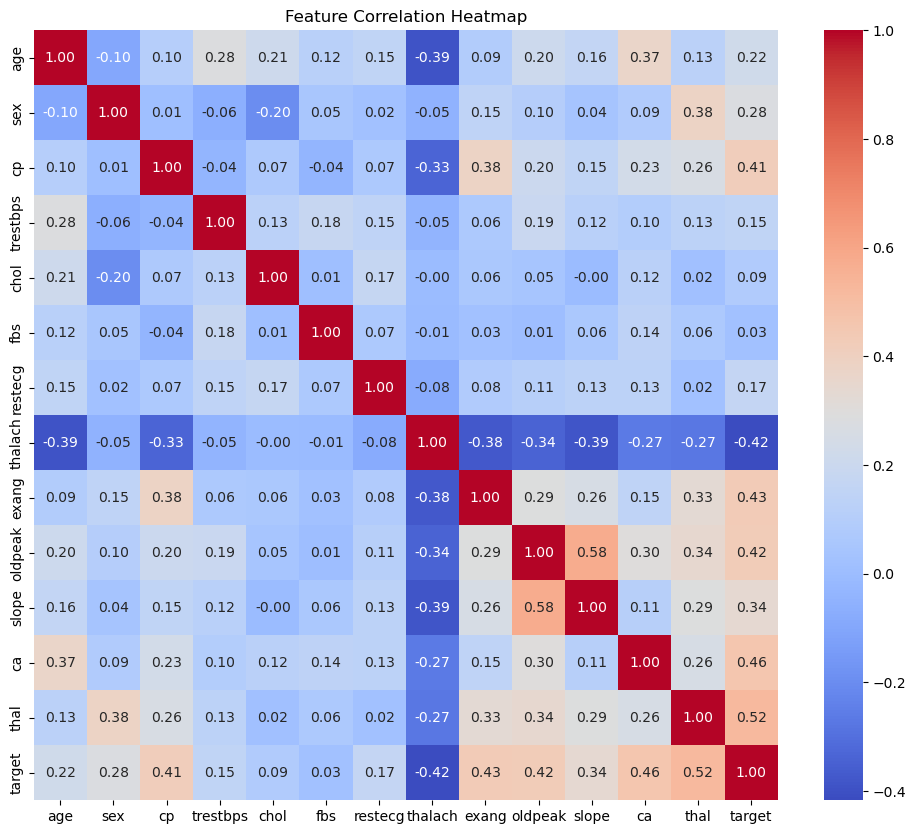

In [4]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


## 4. Train-Test Split & Scaling

We split the data 80/20. We use `StandardScaler` to scale our features because Logistic Regression is sensitive to feature scales.


In [5]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Data scaled successfully.')


Data scaled successfully.


## 5. Model Training: Logistic Regression vs Decision Tree


In [6]:
# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_probs = dt.predict_proba(X_test)[:, 1]

print('Models trained.')


Models trained.


## 6. Evaluation

Let's look at the metrics: Accuracy, ROC-AUC, and Confusion Matrix.


In [7]:
print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, lr_preds):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, lr_probs):.4f}')
print(classification_report(y_test, lr_preds))

print('\n=== Decision Tree ===')
print(f'Accuracy: {accuracy_score(y_test, dt_preds):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, dt_probs):.4f}')
print(classification_report(y_test, dt_preds))


=== Logistic Regression ===
Accuracy: 0.8689
ROC-AUC:  0.9513
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


=== Decision Tree ===
Accuracy: 0.7869
ROC-AUC:  0.8047
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        33
           1       0.73      0.86      0.79        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61



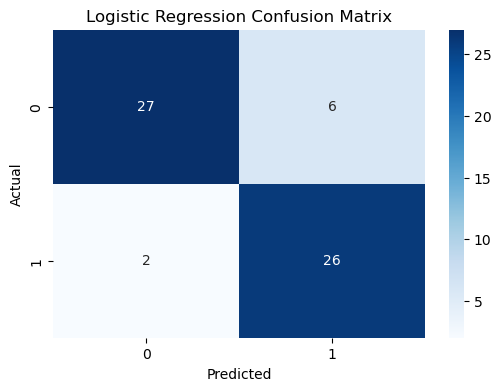

In [8]:
# Confusion Matrix for best model (Logistic Regression)
cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 7. Model Explainability with SHAP

SHAP values tell us exactly *why* the model makes its decisions and which features are most important.


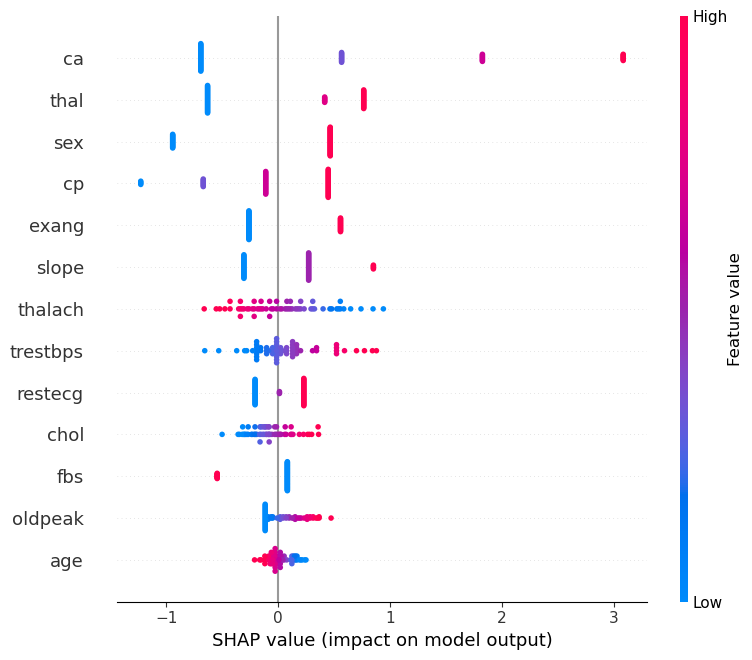

In [9]:
explainer = shap.LinearExplainer(lr, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)
